In [ ]:
import pandas as pd
import json
import glob
import os
import matplotlib.pyplot as plt

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Dropout, Input
from sklearn.preprocessing import RobustScaler, StandardScaler

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
def load_gnss_to_df(directory_path, hour_file_pattern="pvtSolution*.json"):
    all_files = glob.glob(os.path.join(directory_path, hour_file_pattern))
    all_files.sort()

    data_list = []

    target_keys = ['hAcc', 'vAcc', 'sAcc', 'numSV', 'hDOP', 'vDOP', 'clkB', 'clkD', 'gSpeed']

    for file_path in all_files:
        with open(file_path, 'r') as f:
            content = json.load(f)

            clean_content = {}
            min_length = None

            for key in target_keys:
                if key in content and isinstance(content[key], list):
                    clean_content[key] = content[key]
                    if min_length is None:
                        min_length = len(content[key])
                    else:
                        min_length = min(min_length, len(content[key]))

            if clean_content:
                for key in clean_content:
                    clean_content[key] = clean_content[key][:min_length]

                df_temp = pd.DataFrame(clean_content)
                data_list.append(df_temp)

    if not data_list:
        print(f"Brak plików w {directory_path} lub pliki są puste/uszkodzone.")
        return pd.DataFrame()

    return pd.concat(data_list, ignore_index=True)

In [49]:
path_sept = 'dataset/Processed data/21'
path_dec = 'dataset/1221'

df_train_raw = load_gnss_to_df(path_sept)
df_test_raw = load_gnss_to_df(path_dec)

print(f"Wczytano {len(df_train_raw)} próbek treningowych i {len(df_test_raw)} testowych.")

Wczytano 86296 próbek treningowych i 17976 testowych.


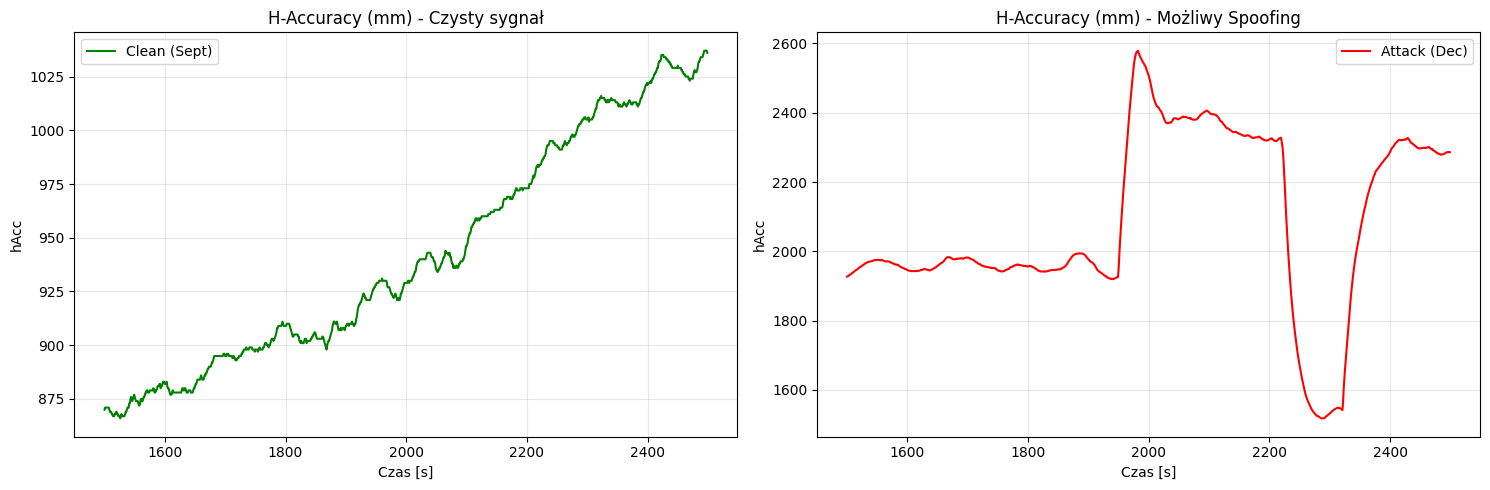

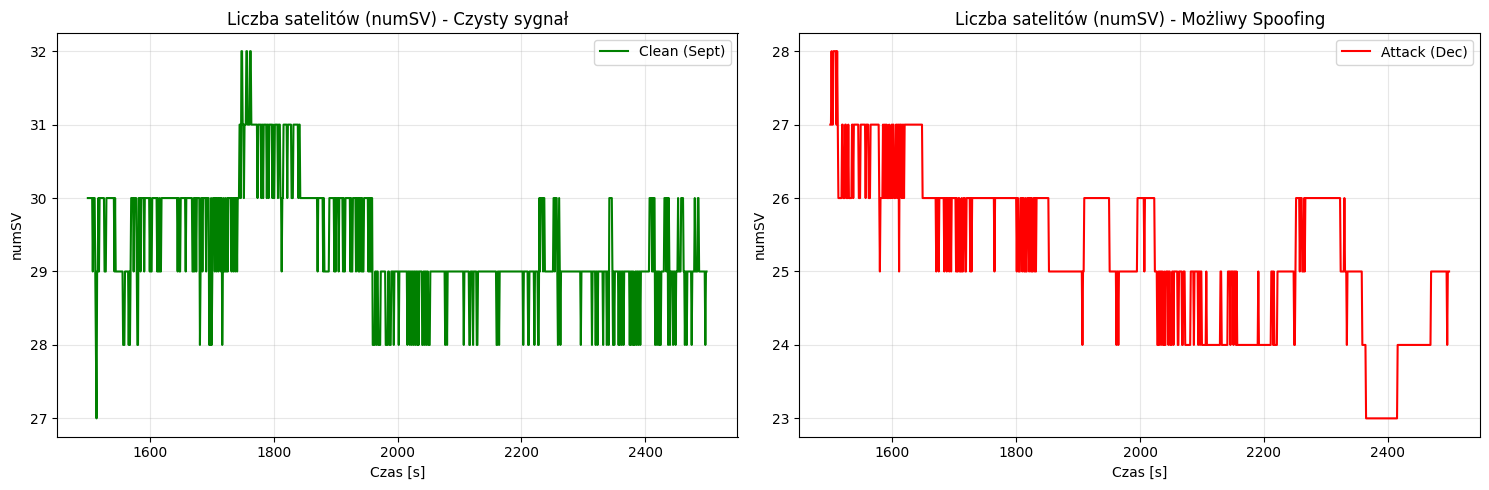

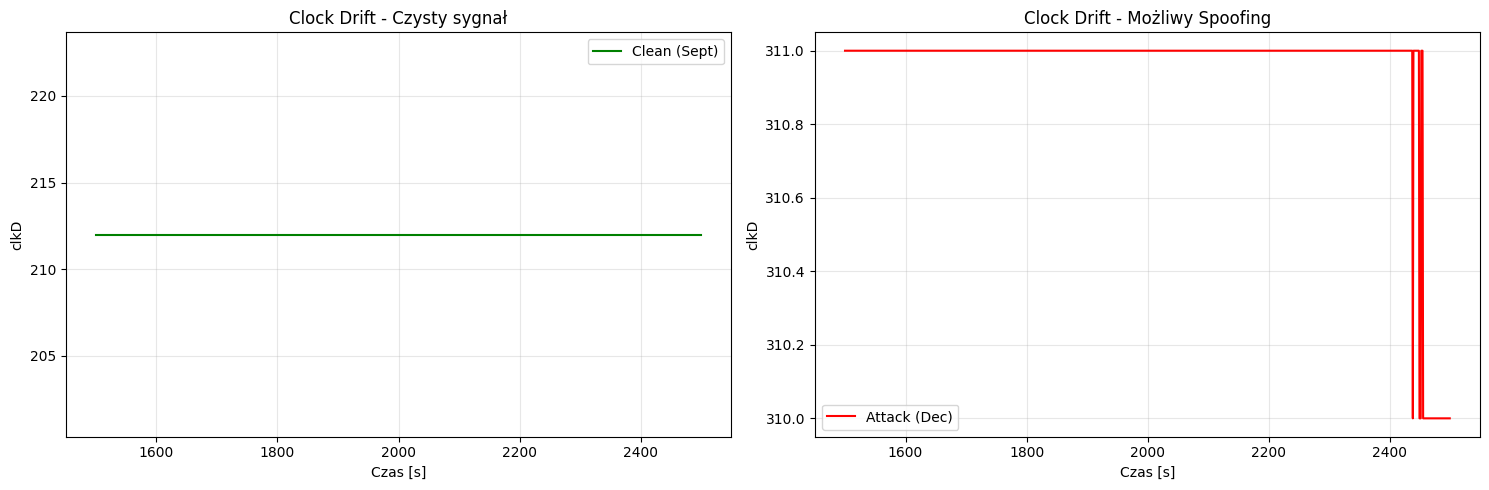

In [ ]:
def plot_gnss_comparison(df_train, df_test, feature='hAcc', title="Porównanie parametru"):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.plot(df_train[feature][1500:2500], color='green', label='Clean (Sept)')
    plt.title(f"{title} - Czysty sygnał")
    plt.ylabel(feature)
    plt.xlabel("Czas [s]")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(df_test[feature][1500:2500], color='red', label='Attack (Dec)')
    plt.title(f"{title} - Możliwy Spoofing")
    plt.ylabel(feature)
    plt.xlabel("Czas [s]")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_gnss_comparison(df_train_raw, df_test_raw, feature='hAcc', title="H-Accuracy (mm)")

plot_gnss_comparison(df_train_raw, df_test_raw, feature='numSV', title="Liczba satelitów (numSV)")

plot_gnss_comparison(df_train_raw, df_test_raw, feature='clkD', title="Clock Drift")

In [51]:
def extract_advanced_features(df):
    data = df.copy()

    data['hAcc_std'] = data['hAcc'].rolling(window=10).std()

    data['numSV_diff'] = data['numSV'].diff().abs()

    data['clkD_velocity'] = data['clkD'].diff().abs()

    return data.dropna()

df_train_ext = extract_advanced_features(df_train_raw)
df_test_ext = extract_advanced_features(df_test_raw)

In [52]:
df_train_raw.isnull().sum()

hAcc      0
vAcc      0
sAcc      0
numSV     0
hDOP      0
vDOP      0
clkB      0
clkD      0
gSpeed    0
dtype: int64

In [ ]:


final_features = ['hAcc', 'hAcc_std', 'numSV', 'numSV_diff', 'clkD', 'clkD_velocity']

scaler = RobustScaler()
train_scaled = scaler.fit_transform(df_train_ext[final_features])
test_scaled = scaler.transform(df_test_ext[final_features])

def create_sequences(data, time_steps=30):
    X = []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps)])
    return np.array(X)

X_train = create_sequences(train_scaled)
X_test = create_sequences(test_scaled)

model = Sequential([
    LSTM(64, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    Dropout(0.2),
    
    LSTM(32, activation='tanh', return_sequences=False),
    Dropout(0.2),
    
    RepeatVector(X_train.shape[1]),
    
    LSTM(32, activation='tanh', return_sequences=True),
    Dropout(0.2),
    LSTM(64, activation='tanh', return_sequences=True),
    
    TimeDistributed(Dense(X_train.shape[2]))
])

model.compile(optimizer='adam', loss='mae')

c:\Users\kalin\Desktop\kościuszkon\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=0.00001,
        verbose=1
    )
]

history = model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 61s 47ms/step - loss: 0.1751 - val_loss: 0.1018 - learning_rate: 0.0010
Epoch 2/50
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 64s 32ms/step - loss: 0.1413 - val_loss: 0.0896 - learning_rate: 0.0010
Epoch 3/50
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - loss: 0.1311 - val_loss: 0.0843 - learning_rate: 0.0010
Epoch 4/50
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 39s 32ms/step - loss: 0.1242 - val_loss: 0.0821 - learning_rate: 0.0010
Epoch 5/50
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 39s 32ms/step - loss: 0.1204 - val_loss: 0.0832 - learning_rate: 0.0010
Epoch 6/50
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 61s 50ms/step - loss: 0.1170 - val_loss: 0.0764 - learning_rate: 0.0010
Epoch 7/50
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 48s 40ms/step - loss: 0.1128 - val_loss: 0.0735 - learning_rate: 0.0010
Epoch 8/50
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 44s 36ms/step - loss: 0.1102 - val_loss: 0.0740 - learning_rate: 0.0010
Epoch 9/50
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - loss: 0.1080 - val_loss: 0.072

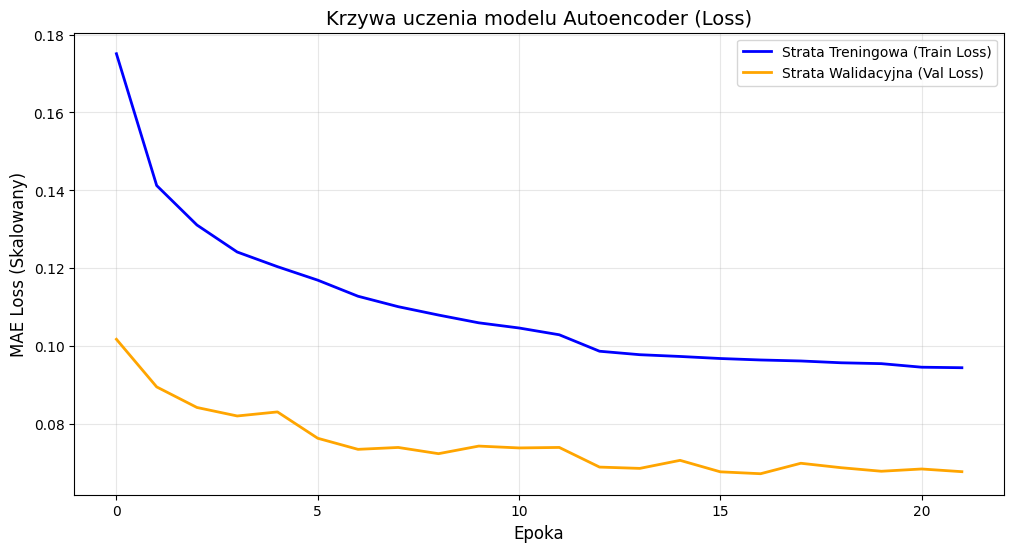

In [ ]:
def plot_learning_history(history):
    plt.figure(figsize=(12, 6))

    plt.plot(history.history['loss'], label='Strata Treningowa (Train Loss)', color='blue', lw=2)
    plt.plot(history.history['val_loss'], label='Strata Walidacyjna (Val Loss)', color='orange', lw=2)

    plt.title('Krzywa uczenia modelu Autoencoder (Loss)', fontsize=14)
    plt.xlabel('Epoka', fontsize=12)
    plt.ylabel('MAE Loss (Skalowany)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()


    plt.show()

plot_learning_history(history)

In [64]:
X_train_pred = model.predict(X_train)
train_mae_loss = np.mean(np.abs(X_train_pred - X_train), axis=(1, 2))

threshold = np.percentile(train_mae_loss, 99.5)
print(f"Próg detekcji (Threshold): {threshold}")
print("Średnie MAE Loss na zbiorze treningowym:", np.mean(train_mae_loss))

2696/2696 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step
Próg detekcji (Threshold): 0.20558439888743152
Średnie MAE Loss na zbiorze treningowym: 0.07581539717054492


In [80]:
threshold = np.percentile(train_mae_loss, 99.6)
print(f"Próg detekcji (Threshold): {threshold}")

Próg detekcji (Threshold): 0.2140139364332037


In [86]:
threshold = 0.5

430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step


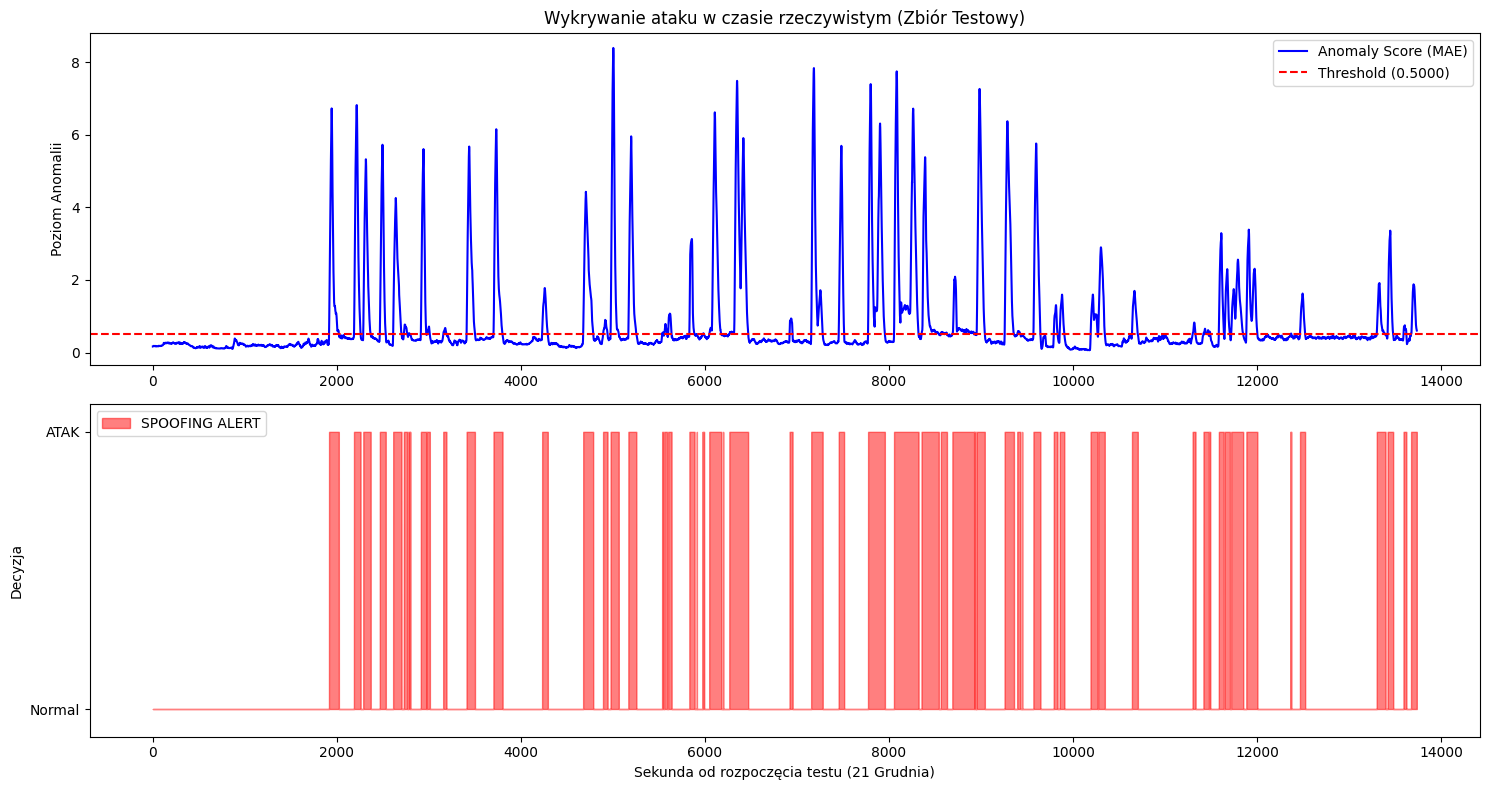

In [87]:
X_test = X_test[:-600]
X_test_pred = model.predict(X_test)

scores = np.mean(np.abs(X_test_pred - X_test), axis=(1, 2))


predictions = [1 if s > threshold else 0 for s in scores]

plt.figure(figsize=(15, 8))

plt.subplot(2, 1, 1)
plt.plot(scores, label='Anomaly Score (MAE)', color='blue')
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.4f})')
plt.title("Wykrywanie ataku w czasie rzeczywistym (Zbiór Testowy)")
plt.ylabel("Poziom Anomalii")
plt.legend()

plt.subplot(2, 1, 2)
plt.fill_between(range(len(predictions)), predictions, color='red', alpha=0.5, label='SPOOFING ALERT')
plt.ylim(-0.1, 1.1)
plt.yticks([0, 1], ['Normal', 'ATAK'])
plt.xlabel("Sekunda od rozpoczęcia testu (21 Grudnia)")
plt.ylabel("Decyzja")
plt.legend()

plt.tight_layout()
plt.show()

In [88]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

raw_attacks = [
    ("12:32:30", "12:37:00"), ("12:38:41", "12:41:20"), ("12:44:05", "12:55:50"),
    ("12:57:00", "13:02:00"), ("13:18:30", "13:23:40"), ("13:27:50", "13:37:50"),
    ("13:37:00", "13:46:00"), ("13:47:10", "13:56:00"), ("13:56:05", "13:59:59"),
    ("14:05:00", "14:10:18"), ("14:12:00", "14:15:00"), ("14:18:00", "14:30:00"),
    ("14:35:00", "14:40:15"), ("14:45:00", "14:50:30"), ("14:52:00", "14:58:00"),
    ("15:11:00", "15:15:00"), ("15:17:00", "15:30:00"), ("15:43:00", "15:48:00"),
    ("15:55:00", "16:00:00"), ("16:10:00", "16:15:30"), ("16:20:00", "16:23:00"),
    ("16:30:00", "16:36:00"), ("16:40:00", "16:44:00")
]

def get_ground_truth(n_samples, start_hour=12):
    y_true = np.zeros(n_samples)
    for start_s, end_s in raw_attacks:
        h1, m1, s1 = map(int, start_s.split(':'))
        h2, m2, s2 = map(int, end_s.split(':'))

        t_start = (h1 - start_hour) * 3600 + m1 * 60 + s1
        t_end = (h2 - start_hour) * 3600 + m2 * 60 + s2

        if t_start < n_samples:
            y_true[t_start:min(t_end, n_samples)] = 1
    return y_true

y_true = get_ground_truth(len(predictions))

In [84]:
delays = []
for start_s, end_s in raw_attacks:
    h1, m1, s1 = map(int, start_s.split(':'))
    t_start = (h1 - 12) * 3600 + m1 * 60 + s1

    if t_start < len(predictions):
        window = predictions[t_start : t_start + 60]
        if 1 in window:
            delay = np.where(np.array(window) == 1)[0][0]
            delays.append(delay)

if delays:
    print(f"Średni czas reakcji na atak: {np.mean(delays):.2f} sekund")

Średni czas reakcji na atak: 0.00 sekund


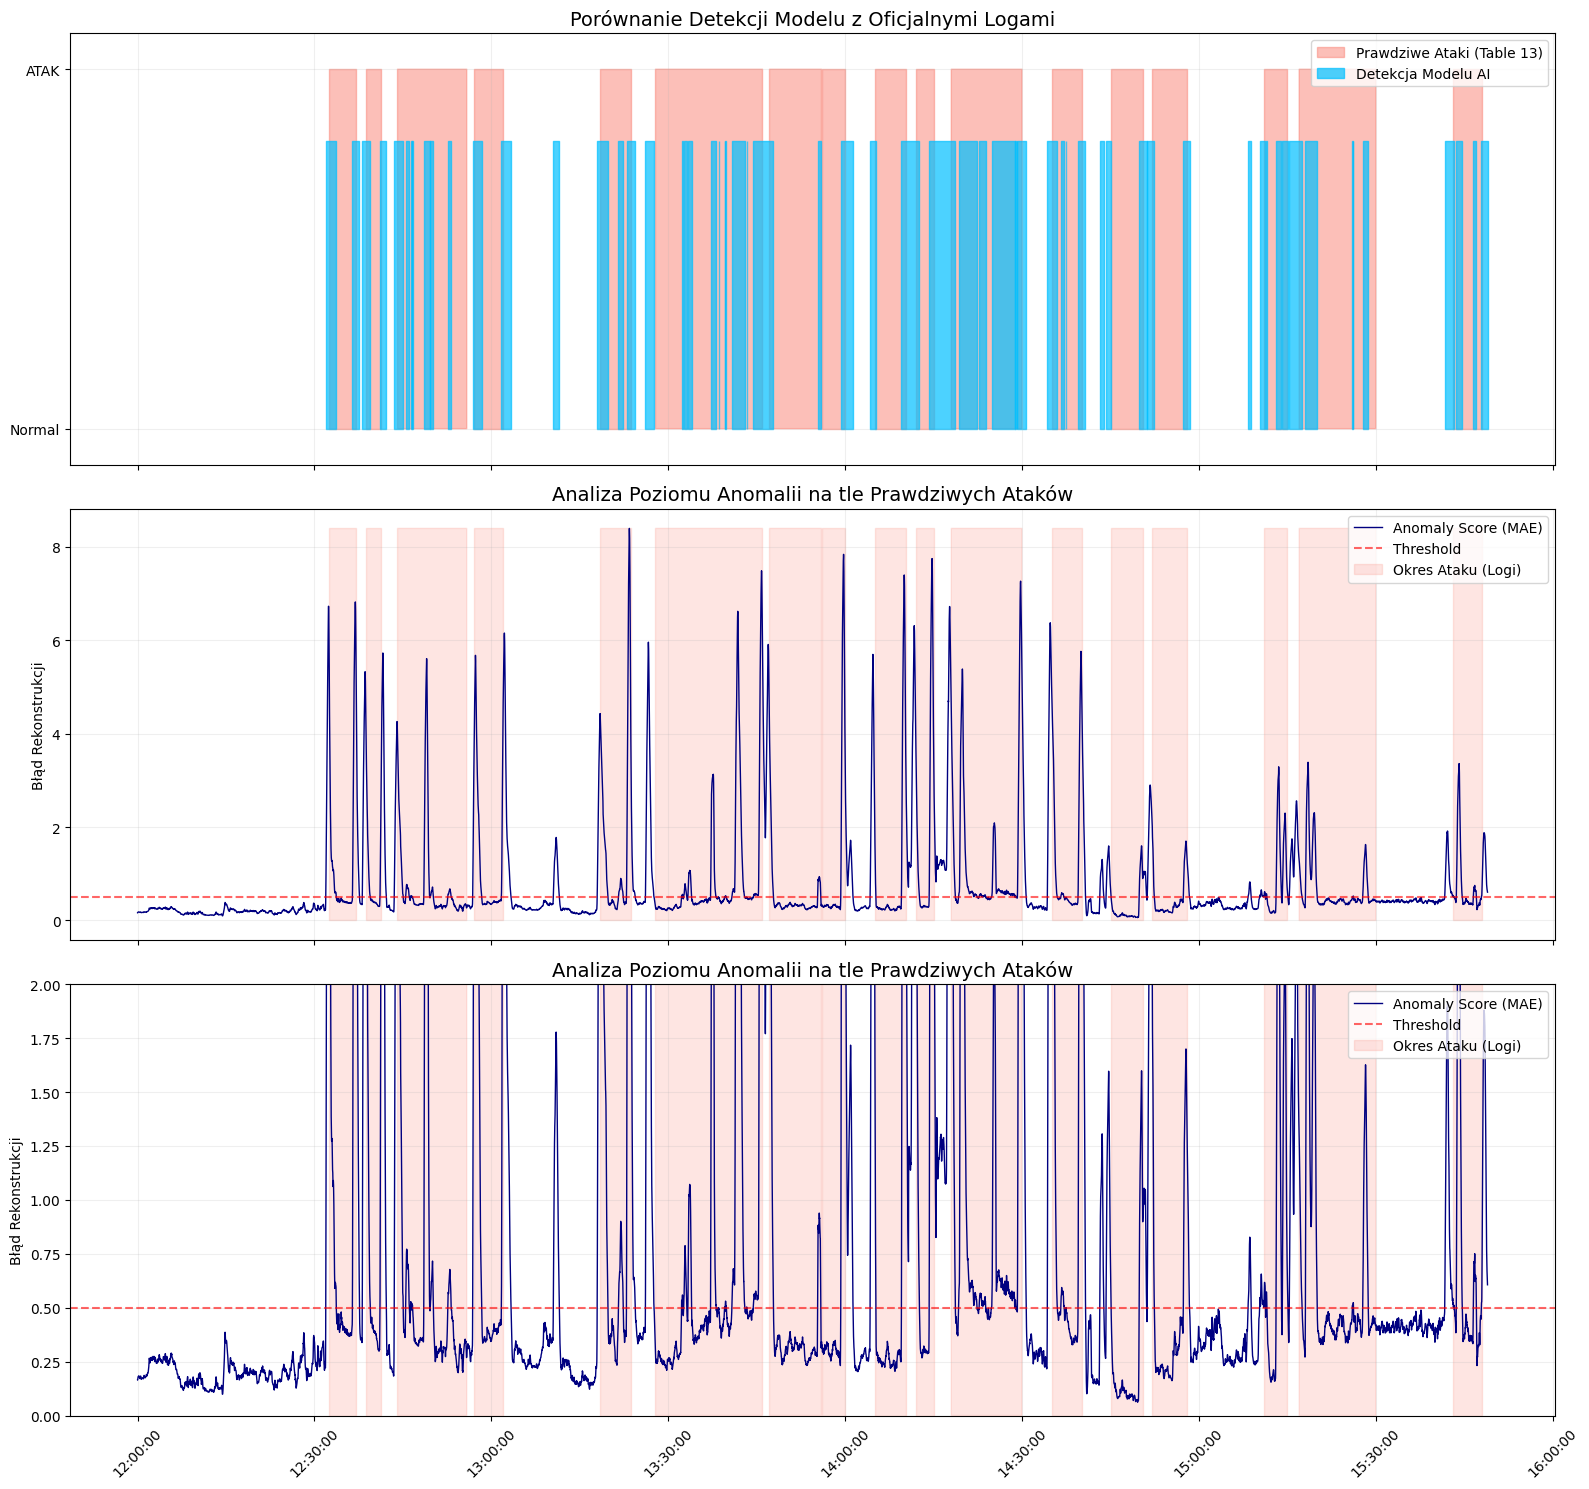

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

start_time = datetime.strptime("12:00:00", "%H:%M:%S")
time_axis = [start_time + timedelta(seconds=i) for i in range(len(scores))]
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 15), sharex=True)

ax1.fill_between(time_axis, 0, 1, where=np.array(y_true)==1,
                 color='salmon', alpha=0.5, label='Prawdziwe Ataki (Table 13)')

ax1.fill_between(time_axis, 0, 0.8, where=np.array(predictions)==1,
                 color='deepskyblue', alpha=0.7, label='Detekcja Modelu AI')

ax1.set_ylim(-0.1, 1.1)
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['Normal', 'ATAK'])
ax1.set_title("Porównanie Detekcji Modelu z Oficjalnymi Logami", fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.2)

ax2.plot(time_axis, scores, color='navy', lw=1, label='Anomaly Score (MAE)')
ax2.axhline(y=threshold, color='red', linestyle='--', alpha=0.6, label='Threshold')
ax2.fill_between(time_axis, 0, max(scores), where=np.array(y_true)==1,
                 color='salmon', alpha=0.2, label='Okres Ataku (Logi)')

ax2.set_ylabel("Błąd Rekonstrukcji")
ax2.set_title("Analiza Poziomu Anomalii na tle Prawdziwych Ataków", fontsize=14)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.2)

ax3.plot(time_axis, scores, color='navy', lw=1, label='Anomaly Score (MAE)')
ax3.axhline(y=threshold, color='red', linestyle='--', alpha=0.6, label='Threshold')
ax3.set_ylim(0, 2.0)
ax3.fill_between(time_axis, 0, max(scores), where=np.array(y_true)==1,
                 color='salmon', alpha=0.2, label='Okres Ataku (Logi)')

ax3.set_ylabel("Błąd Rekonstrukcji")
ax3.set_title("Analiza Poziomu Anomalii na tle Prawdziwych Ataków (przybliżenie)", fontsize=14)
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.2)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [95]:
model.save('lstm1.keras')